# Diabetes Dataset XGBoost 회귀

## 개요
- scikit-learn `load_diabetes` 회귀 데이터셋으로 **질병 진행 정도(연속값)** 예측
- XGBoost Regressor로 성능 향상 및 하이퍼파라미터 최적화(GridSearchCV)
- 평가 지표: **R2**, **RMSE**

## 주요 단계
1. 데이터 로드 및 분리
2. XGBoost Regressor 설정
3. GridSearchCV 최적화
4. 성능 평가 및 피처 중요도 분석


## 라이브러리 임포트

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from xgboost import XGBRegressor, plot_importance
from sklearn.metrics import r2_score, mean_squared_error


## 1. 데이터 로드

In [2]:
print("Loading Diabetes Regression Dataset...")
diabetes = load_diabetes(as_frame=True)

X = diabetes.data
y = diabetes.target

print(f"데이터 크기: {X.shape}")
print(f"타깃 크기: {y.shape}")
print(f"피처 목록: {list(X.columns)}")
print(f"타깃(연속값) 요약: min={y.min():.2f}, max={y.max():.2f}, mean={y.mean():.2f}")


Loading Diabetes Regression Dataset...
데이터 크기: (442, 10)
타깃 크기: (442,)
피처 목록: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
타깃(연속값) 요약: min=25.00, max=346.00, mean=152.13


**데이터 샘플 확인**

In [3]:
# 데이터 샘플
print("\n데이터 샘플:")
display(X.head())

print("\n기술 통계:")
display(X.describe())



데이터 샘플:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641



기술 통계:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01


**학습/테스트 데이터 분리**

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")


Train: (353, 10), Test: (89, 10)


## 2. XGBoost Regressor

**모델 설정**

In [5]:
# XGBoost Regressor
xgb_reg = XGBRegressor(
    random_state=42,
    objective='reg:squarederror'
)

print("XGBoost Regressor 생성")
print("기본 설정: objective='reg:squarederror'")


XGBoost Regressor 생성
기본 설정: objective='reg:squarederror'


## 3. GridSearchCV 하이퍼파라미터 탐색

In [6]:
# 하이퍼파라미터 그리드 (요청 코드 기반)
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5],
    'subsample': [0.7, 0.9],
    'reg_alpha': [0, 0.1],   # L1 규제 (Lasso 유사)
    'reg_lambda': [1, 1.5]   # L2 규제 (Ridge 유사)
}

print("파라미터 그리드:")
for param, values in param_grid.items():
    print(f"  {param}: {values}")

total_combinations = 1
for values in param_grid.values():
    total_combinations *= len(values)
print(f"\n총 조합 수: {total_combinations}개")


파라미터 그리드:
  n_estimators: [100, 200, 300]
  learning_rate: [0.01, 0.05, 0.1]
  max_depth: [3, 5]
  subsample: [0.7, 0.9]
  reg_alpha: [0, 0.1]
  reg_lambda: [1, 1.5]

총 조합 수: 144개


In [7]:
# GridSearchCV
print("\nTuning XGBoost Regressor...")
print("(교차검증 수행 중...)\n")

grid_reg = GridSearchCV(
    xgb_reg,
    param_grid,
    cv=KFold(5, shuffle=True, random_state=42),
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_reg.fit(X_train, y_train)
print("\nGridSearchCV 완료!")



Tuning XGBoost Regressor...
(교차검증 수행 중...)

Fitting 5 folds for each of 144 candidates, totalling 720 fits

GridSearchCV 완료!


## 4. 최적화 결과 분석

In [8]:
# 최적 모델 추출
best_reg = grid_reg.best_estimator_

print("[최적화 결과]")
print(f"Best R2 Score (Train CV): {grid_reg.best_score_:.4f}")
print("\nBest Parameters:")
for param, value in grid_reg.best_params_.items():
    print(f"  {param}: {value}")


[최적화 결과]
Best R2 Score (Train CV): 0.4301

Best Parameters:
  learning_rate: 0.01
  max_depth: 3
  n_estimators: 300
  reg_alpha: 0
  reg_lambda: 1
  subsample: 0.7


**GridSearchCV 상위 결과**

In [9]:
# 상위 5개 결과
cv_results = pd.DataFrame(grid_reg.cv_results_)

# 보기 좋은 컬럼만 선택(존재하는 것만)
candidate_cols = [
    'param_n_estimators', 'param_learning_rate', 'param_max_depth', 'param_subsample',
    'param_reg_alpha', 'param_reg_lambda', 'mean_test_score', 'std_test_score', 'rank_test_score'
]
cols = [c for c in candidate_cols if c in cv_results.columns]

top_results = cv_results.nsmallest(5, 'rank_test_score')[cols]

print("\n상위 5개 파라미터 조합:")
display(top_results)



상위 5개 파라미터 조합:


,param_n_estimators,param_learning_rate,param_max_depth,param_subsample,param_reg_alpha,param_reg_lambda,mean_test_score,std_test_score,rank_test_score
16,300,0.01,3,0.7,0.0,1.0,0.430134,0.033558,1
18,300,0.01,3,0.7,0.0,1.5,0.429551,0.032656,2
22,300,0.01,3,0.7,0.1,1.5,0.429397,0.032686,3
20,300,0.01,3,0.7,0.1,1.0,0.429381,0.034385,4
52,100,0.05,3,0.7,0.1,1.0,0.419185,0.033289,5


## 5. 테스트 데이터 평가

In [10]:
# 테스트 데이터 예측 및 평가
y_pred = best_reg.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Test RMSE: {rmse:.4f}")
print(f"Test R2 Score: {r2:.4f}")


Test RMSE: 52.1735
Test R2 Score: 0.4862


## 6. 피처 중요도 분석

**XGBoost 내장 시각화**

<Figure size 1000x800 with 0 Axes>

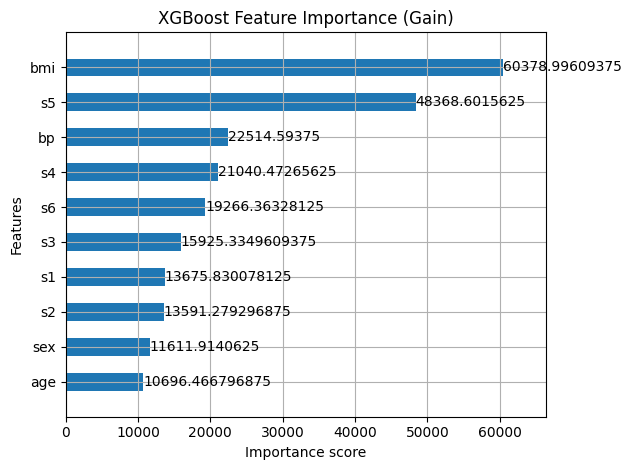

In [12]:
# XGBoost plot_importance (Gain)
plt.figure(figsize=(10, 8))
plot_importance(best_reg, max_num_features=10,
                importance_type='gain', height=0.5)
plt.title("XGBoost Feature Importance (Gain)")
plt.tight_layout()
plt.show()


**수동 피처 중요도 추출 및 시각화**


피처 중요도 순위:


,Feature,Importance
0,bmi,0.254689
1,s5,0.204027
2,bp,0.094970
3,s4,0.088752
4,s6,0.081269
5,s3,0.067176
6,s1,0.057687
7,s2,0.057330
8,sex,0.048981
9,age,0.045119


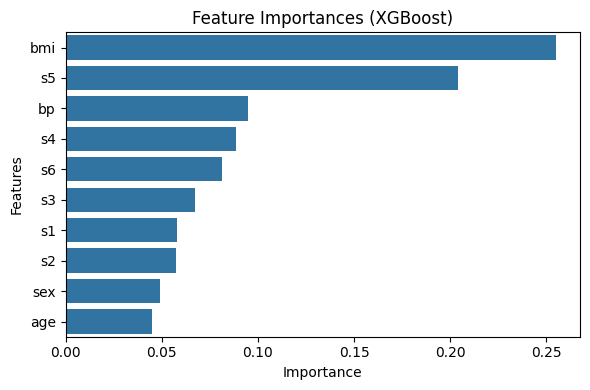

In [14]:
# 피처 중요도 추출
importances = best_reg.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1]

importance_df = pd.DataFrame({
    'Feature': feature_names[indices],
    'Importance': importances[indices]
})

print("\n피처 중요도 순위:")
display(importance_df)

plt.figure(figsize=(6, 4))
sns.barplot(x=importance_df['Importance'], y=importance_df['Feature'])
plt.title("Feature Importances (XGBoost)")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.tight_layout()
plt.show()
